# A specific null model for coordinate-based meta-analyses

> **WARNING**: This functionality is experimental and requires further testing!

> **Requires:** `pip install nimare`

*Coordinate-based meta-analysis (CBMA)* aggregates reported peak activation coordinates across many neuroimaging studies to identify brain regions that are consistently activated for a given cognitive domain or clinical population. [NiMARE](https://nimare.readthedocs.io) is a Python library for neuroimaging meta-analyses, including ALE (Activation Likelihood Estimation) — this notebook uses NiMARE to run an ALE analysis on a pain dataset and then feeds the result into NiSpace for colocalization with PET receptor reference maps.

In [2]:
import tqdm.notebook
tqdm.notebook.tqdm = tqdm.tqdm

import numpy as np
import pandas as pd

import nimare
from nimare.meta.cbma import ALE
from nimare.correct import FWECorrector
from nimare.tests.utils import get_test_data_path

from nispace import NiSpace, null_maps_from_nimare, get_binary_cluster_map
from nispace.datasets import fetch_reference
from nispace.plotting import brainplot
from nispace.workflows import nimare_colocalization, colocalization

# parcellation to use
PARC = "Yan200+TianS2"

## Why a special null model for meta-analytic maps?

**Standard spatial null models may test the wrong thing here.** Moran spectral randomization and spin tests generate surrogates that preserve the *spatial autocorrelation (SA)* of the observed map. They ask: "is this colocalization stronger than we would expect from two spatially autocorrelated maps of similar smoothness, correlated by chance?" This is the right question for a single observed brain image — a PET scan, an fMRI contrast, a group-level Cohen's d map — where SA is an intrinsic property of the measurement.

**ALE maps have a different generative model.** An ALE map is the output of a process: study peak coordinates → Gaussian activation kernels → summed probability field. The SA in the resulting image reflects the *spatial clustering of reported peaks across studies*, not measurement noise or biological SA. When you ask whether a pain ALE map colocalizes with serotonin receptor density, your hypothesis may often be: *do the brain regions consistently reported in the pain literature overlap with serotonin-rich areas more than would be expected if those peak coordinates had no specific spatial preference?* This is a question about the generative process — the distribution of input coordinates — not about the spatial smoothness of the output image.

**The coordinate-sampling null.** NiMARE's own FWE correction already answers this question internally: for each permutation it replaces all study coordinates with random draws from the brain mask and recomputes the ALE map. `null_maps_from_nimare()` re-implements this loop at the parcellated level, so the same principled null can be used for colocalization testing in NiSpace. We will compare it with the standard Moran-on-X null empirically below — the two approaches are complementary and test subtly different hypotheses.

## ALE analysis: the pain dataset

We use NiMARE's built-in pain test dataset — a collection of peak activation coordinates from pain neuroimaging studies.

In [3]:
# Load the NiMARE pain dataset
dset_path = get_test_data_path() + "/test_pain_dataset.json"
dset = nimare.dataset.Dataset(dset_path)
print(f"Dataset: {len(dset.ids)} studies, {len(dset.coordinates)} peak coordinates")

Dataset: 21 studies, 243 peak coordinates


### The ALE maps: continuous and binary

Two output types are relevant for NiSpace colocalization:

**Continuous ALE stat map** (`result.get_map("stat")`)   
Raw ALE value at each voxel, in \[0, 1\] — the probability of activation given the kernel model. Captures the full graded spatial structure of the meta-analysis.

**FWE-corrected binary cluster map** (`get_binary_cluster_map(corrected)`)  
A 0/1 image marking only the regions that survive family-wise error correction (voxel-level CDT + cluster extent threshold) — the "significant pain network".

Both can serve as Y in NiSpace. The continuous map preserves more spatial information; the binary map focuses colocalization on the statistically significant regions only.

> **Note on thresholding:** NiMARE's cluster-corrected logp maps contain values for *all* suprathreshold clusters, including non-significant ones (0 < logp < 1.301 for α=0.05). `get_binary_cluster_map()` applies the correct threshold `logp ≥ −log10(α)` — using a plain `> 0` threshold would include far too many voxels.

In [4]:
# Run ALE
ale_result = ALE().fit(dset)
print(f"ALE result maps: {[k for k, v in ale_result.maps.items() if v is not None]}")

# FWE cluster correction (1000 iterations; may take a few minutes)
ale_fwe = FWECorrector(method="montecarlo", voxel_thresh=0.001, n_iters=1000, n_cores=-1)
ale_corrected = ale_fwe.transform(ale_result)

# get the results maps
ale_img = ale_result.get_map("stat")
binary_img = get_binary_cluster_map(ale_corrected, cluster_stat="size", alpha=0.05)
print(f"Significant voxels in binary map: {int(binary_img.get_fdata().sum())}")

INFO:nimare.dataset:Retaining 19/21 studies


INFO:nimare.correct:Using correction method implemented in Estimator: nimare.meta.cbma.ale.ALE.correct_fwe_montecarlo.


ALE result maps: ['stat', 'p', 'z']


/Applications/miniforge3/envs/nsp309/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [01:22<00:00, 12.13it/s]

INFO:nimare.meta.cbma.base:Using null distribution for voxel-level FWE correction.


INFO:nispace.helpers.nimare:Binary cluster map from 'logp_desc-size_level-cluster_corr-FWE_method-montecarlo' (logp >= 1.3010, alpha=0.05): 2436 significant voxels.


Significant voxels in binary map: 2436


(<Figure size 720x180 with 6 Axes>, [<Axes: >])

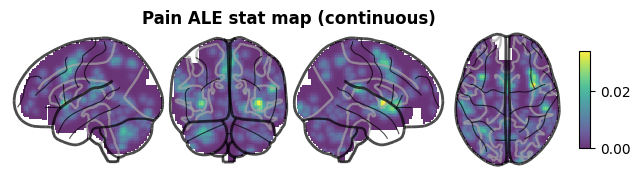

In [5]:
# Continuous ALE stat map
brainplot(ale_img, title="Pain ALE stat map (continuous)", colorbar=True, threshold=0)

(<Figure size 720x180 with 5 Axes>, [<Axes: >])

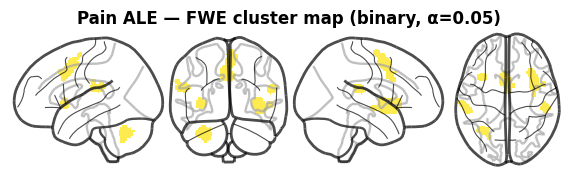

In [6]:
# FWE-corrected binary cluster map
brainplot(binary_img, title="Pain ALE — FWE cluster map (binary, α=0.05)", colorbar=False)

## NiMARE coordinate-sampling null (continuous mode)

Now let's use the coordinate-sampling null. Y is the same ALE stat map; the null maps are generated by re-running ALE with random coordinates.  

Our main function: `nispace.helpers.null_maps_from_nimare`

`map_label` must match `y_labels`. The dict returned by `null_maps_from_nimare()` has the label as key. NiSpace looks up the null array by matching this key to the Y-map label. A mismatch raises an error.

### 1: Fetch reference data

In [7]:
# Load PET receptor reference maps (cortical, Yan200 parcellation)
pet_maps = fetch_reference(
    "pet", 
    parcellation=PARC,
    collection="UniqueTracers", 
    print_references=False
)
print(f"PET maps: {pet_maps.shape[0]} receptors, {pet_maps.shape[1]} parcels")

INFO:nispace.datasets:Loading pet maps.


INFO:nispace.datasets:Loading integrated collection 'UniqueTracers' for dataset 'pet'.


INFO:nispace.datasets:Filtering maps by collection.


INFO:nispace.datasets:Loading and inner-merging data parcellated with 'Yan200' and 'TianS2'


PET maps: 29 receptors, 232 parcels


### 2: Generate NiMARE null maps

In [8]:
# Generate coordinate-sampling null maps (re-runs ALE with random coordinates)
null_maps = null_maps_from_nimare(
    ale_result, 
    parcellation=PARC,
    outcome_map="stat",
    map_label="pain_ale",   # must match y_labels above
    observed_map=ale_img,   # triggers sanity check (r ≥ 0.99)
    n_perm=1000,
    seed=42,
    n_proc=-1,
)
print(f"Null maps shape: {null_maps['pain_ale'].shape}")

INFO:nispace.helpers.nimare:Fetching parcellation 'Yan200+TianS2' for null map generation.


INFO:nispace.core.parcellation:Building combined Parcellation 'Yan200+TianS2' from library.


INFO:nispace.core.parcellation:  Common MNI space(s) for combined: ['MNI152NLin2009cAsym', 'MNI152NLin6Asym'].


INFO:nispace.core.parcellation:  Merging 'Yan200' and 'TianS2' for space 'MNI152NLin2009cAsym'.


INFO:nispace.core.parcellation:  Merging 'Yan200' and 'TianS2' for space 'MNI152NLin6Asym'.


...


INFO:nispace.helpers.nimare:Done. null_maps['pain_ale'] shape: (1000, 232)


INFO:nispace.helpers.nimare:=== Validation (continuous mode) ===


INFO:nispace.helpers.nimare:  Empirical p (our null) vs NiMARE parametric p-map: Spearman r=0.973  (p=0.0000)


INFO:nispace.helpers.nimare:  Note: NiMARE p is voxelwise-approximate; ours is parcel-level Monte Carlo — perfect agreement is not expected, but r should be high.


Null maps shape: (1000, 232)


### 3: Run the analysis

INFO:nispace.api:*** NiSpace.fit() - Data extraction and preparation. ***


INFO:nispace.core.parcellation:Building combined Parcellation 'Yan200+TianS2' from library.


INFO:nispace.core.parcellation:  Common MNI space(s) for combined: ['MNI152NLin2009cAsym', 'MNI152NLin6Asym'].


INFO:nispace.core.parcellation:  Merging 'Yan200' and 'TianS2' for space 'MNI152NLin2009cAsym'.


INFO:nispace.core.parcellation:  Merging 'Yan200' and 'TianS2' for space 'MNI152NLin6Asym'.


...

INFO:nispace.core.permute:Using provided null maps.


Processing null arrays (-1 proc): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:01<00:00, 626.68it/s]

Null colocalizations (spearman, -1 proc): 100%|████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 2927.18it/s]


INFO:nispace.core.permute:Calculating exact p-values (tails = {'rho': 'two'}).


INFO:nispace.plotting:Significance annotation: 11/29 p_uncorrected < 0.05, 1/29 p_meffgalwey < 0.05


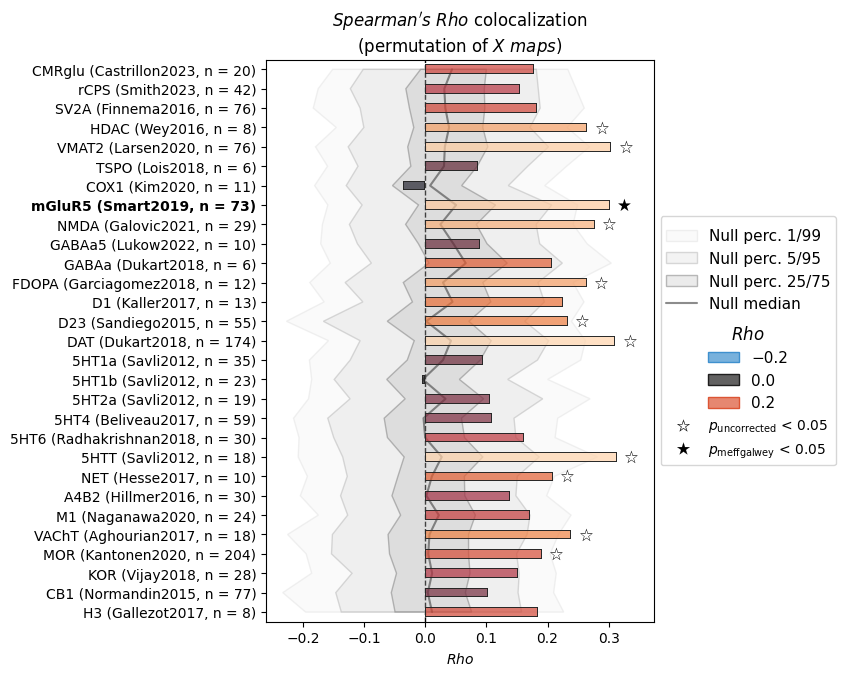

In [9]:
nsp = nimare_colocalization(
    x=pet_maps,
    y={"pain_ale": ale_img},
    parcellation=PARC,
    seed=42, 
    n_proc=-1,
    n_perm=1000,
    nimare_nulls=null_maps,     # here, we pass the nimare nulls
    return_nispace_only=True
)

#### 3.1 Inspect parcellated maps

INFO:nispace.plotting:brainplot: threshold='auto' → 4.604904782143371e-13


INFO:nispace.plotting:brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


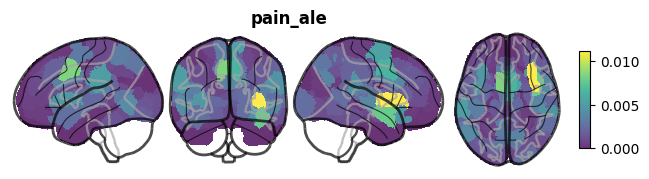

INFO:nispace.core.parcellation:Building combined Parcellation 'Yan200+TianS2' from library.


INFO:nispace.core.parcellation:  Common MNI space(s) for combined: ['MNI152NLin2009cAsym', 'MNI152NLin6Asym'].


INFO:nispace.core.parcellation:  Merging 'Yan200' and 'TianS2' for space 'MNI152NLin2009cAsym'.


INFO:nispace.core.parcellation:  Merging 'Yan200' and 'TianS2' for space 'MNI152NLin6Asym'.


INFO:nispace.core.parcellation:  Fetching cx surface data for 'Yan200' in 'fsLR' (for spin tests).


...

INFO:nispace.core.parcellation:Parcellation 'Yan200+TianS2': validation passed.


INFO:nispace.core.parcellation:Parcellation 'Yan200+TianS2': active space set to 'MNI152NLin2009cAsym'.


INFO:nispace.core.parcellation:Combined parcellation: cx-LH parcels = 100, cx-RH parcels = 100.


INFO:nispace.plotting:brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


(<Figure size 1440x630 with 36 Axes>,
 [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >])

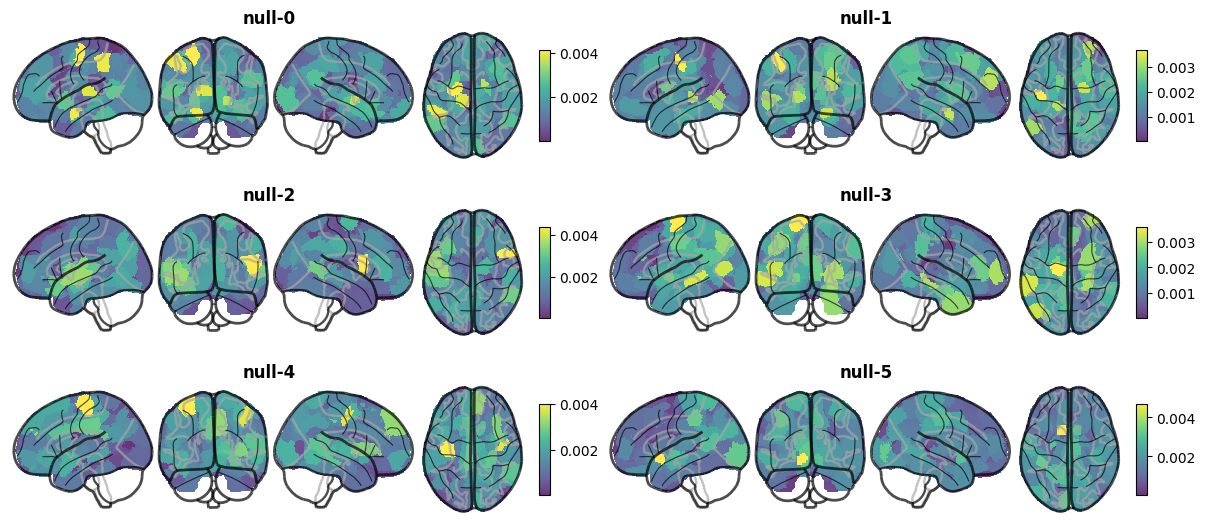

In [10]:
# observed map (now parcellated)
nsp.plot_brain("y")

# null maps (always parcellated)
brainplot(
    null_maps["pain_ale"][:6, :], 
    parcellation=PARC,
    title=[f"null-{i}" for i in range(6)], 
    threshold=0,
    ncols=2
)

#### 3.2: Results

In [11]:
rho = nsp.get_colocalizations()
p_nimare = nsp.get_p_values()
print("p_nimare shape (1 ale map x N pet maps):", p_nimare.shape)

p_nimare shape (1 ale map x N pet maps): (1, 29)


### Extra: Without workflow function

Why `maps_which="Y"`? By default, `permute("maps")` generates surrogates for X (the reference atlas maps) and recomputes correlations against a fixed Y. Here the null model belongs to Y (the meta-analytic image) — we want to ask whether the *observed* PET receptors correlate with the ALE map more than they would with a *random* ALE map. `maps_which="Y"` tells NiSpace to use the provided `maps_nulls` as surrogates for Y while keeping X fixed.

In [12]:
# Set up NiSpace: X=PET receptors, Y=continuous ALE stat map
nsp = NiSpace(
    x=pet_maps, 
    y=ale_img, 
    y_labels=["pain_ale"],
    parcellation=PARC, 
    seed=42, 
    n_proc=-1
)
nsp.fit(ignore_background_data=False)   # CAVE: BACKGROUND SETTING STRICTLY NECESSARY FOR ALE

# Generate nimare nulls (done above -> commented out)
# null_maps = null_maps_from_nimare(
#     ale_result, 
#     parcellation=nsp._parc, # extract the Parcellation object form the fitted NiSpace instance
#     outcome_map="stat",
#     map_label="pain_ale",   # must match y_labels above
#     observed_map=ale_img,   # triggers sanity check (r ≥ 0.99)
#     n_perm=1000,
#     seed=42,
#     n_proc=-1,
# )

# Run colocalization
nsp.colocalize("spearman")

# Permute Y (not X) using the NiMARE null maps
nsp.permute("maps", maps_which="Y", maps_nulls=null_maps, n_perm=1000, p_tails="two")

# correct for multiple comparisons
nsp.correct_p()

INFO:nispace.core.parcellation:Building combined Parcellation 'Yan200+TianS2' from library.


INFO:nispace.core.parcellation:  Common MNI space(s) for combined: ['MNI152NLin2009cAsym', 'MNI152NLin6Asym'].


INFO:nispace.core.parcellation:  Merging 'Yan200' and 'TianS2' for space 'MNI152NLin2009cAsym'.


INFO:nispace.core.parcellation:  Merging 'Yan200' and 'TianS2' for space 'MNI152NLin6Asym'.


INFO:nispace.core.parcellation:  Fetching cx surface data for 'Yan200' in 'fsLR' (for spin tests).


...

INFO:nispace.core.permute:Wrapping provided dict null maps into NullMaps.


INFO:nispace.core.permute:Using provided null maps.


Processing null arrays (-1 proc): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 5164.25it/s]

Null colocalizations (spearman, -1 proc): 100%|████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 8728.22it/s]


INFO:nispace.core.permute:Calculating exact p-values (tails = {'rho': 'two'}).


### Note: Image validation - the `observed_map` sanity check

A brief note on the `observed_map=` parameter in `null_maps_from_nimare()`.

When you pass the same image you fed into NiSpace as `y=`, the function parcellates it internally using the same parcellater and computes Pearson r against the internally computed reference:

- **Continuous mode**: internal reference is `result.get_map(outcome_map)` parcellated with the same parcellater. Pearson r ≥ 0.99 → sanity check passed; r < 0.99 → warning (space or resampling mismatch).
- **Binary cluster mode**: internal reference is the observed z-map re-thresholded and cluster-filtered with the *same parameters* you provided. This confirms that `get_binary_cluster_map()` and the internal pipeline use identical settings.

The check is logged (`Observed-map sanity check passed (r=...)`) or triggers a warning. Always pass `observed_map=` during development — it catches mismatches before they silently corrupt results.

## Comparison to standard spatial colocalization

To put these results in context, we also run the standard `colocalization()` workflow. Here we again permute Y (using `permute_kwargs={"maps_which": "Y"}`), but instead of coordinate-sampling, NiSpace generates **Moran spectral surrogates** of the ALE map — random maps that preserve the spatial autocorrelation of the observed ALE image while scrambling its specific pattern.

This makes the comparison clean: both tests permute Y, but with different null generators:

- **Moran null on Y**: asks whether the *spatial autocorrelation structure* of the ALE map explains the colocalization
- **Coordinate-sampling null on Y**: asks whether the *spatial convergence of peak coordinates* explains the colocalization

Because the ALE map is a volumetric image (no surface projection), and the parcellation `Yan200+TianS2` is a combined atlas, Moran is auto-selected as the null method.

INFO:nispace.workflows:Loading integrated pet dataset as X data.


INFO:nispace.workflows:Using default collection 'UniqueTracers'.


INFO:nispace.datasets:Loading pet maps.


INFO:nispace.datasets:Loading integrated collection 'UniqueTracers' for dataset 'pet'.


INFO:nispace.datasets:Filtering maps by collection.


...

INFO:nispace.nulls:Null data generation finished.


Processing null arrays (-1 proc): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 25801.99it/s]

Null colocalizations (spearman, -1 proc): 100%|█████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 36646.01it/s]


INFO:nispace.core.permute:Calculating exact p-values (tails = {'rho': 'two'}).


INFO:nispace.plotting:Significance annotation: 6/29 p_uncorrected < 0.05, 0/29 p_meffgalwey < 0.05


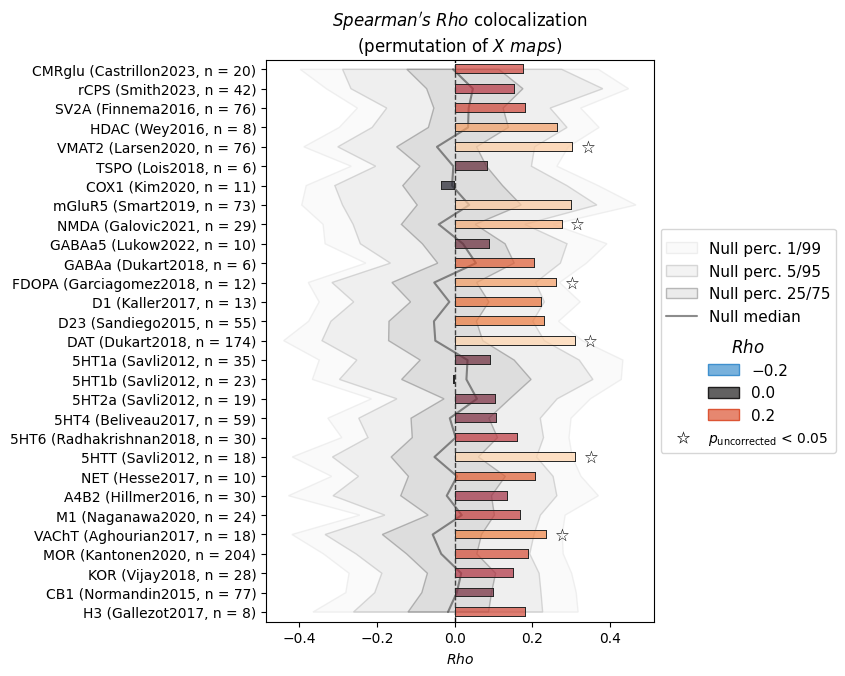

In [13]:
# Standard colocalization workflow (Moran null on X maps)
nsp_standard = colocalization(
    x="pet",
    y={"pain_ale": ale_img},
    parcellation=PARC,
    fit_kwargs={"ignore_background_data": False},   # CAVE: STRICTLY NECESSARY FOR ALE
    permute_kwargs={"maps_which": "Y"},             # for comparison
    seed=42,
    n_proc=-1,
    return_nispace_only=True,
)

# get results
rho_std = nsp_standard.get_colocalizations()
p_std = nsp_standard.get_p_values()


The table below shows both p-value columns side by side:

- `p_moran`: Moran null on Y — tests whether the spatial autocorrelation structure of the ALE map explains the colocalization
- `p_nimare`: coordinate-sampling null on Y — tests whether the spatial convergence of peak coordinates in the meta-analysis explains the colocalization

For most receptors the two are broadly consistent. Meaningful divergence between the two p-values indicates that one of these factors is driving the result — scientifically informative.

Top 10 by NiMARE p-value:


rho  \
set                         map                                                            
Glutamate                   target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smar...  0.301870   
Dopamine                    target-DAT_tracer-fpcit_n-174_dx-hc_pub-dukart2018  0.311011   
Serotonin                   target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012    0.313451   
Glutamate                   target-NMDA_tracer-ge179_n-29_dx-hc_pub-galovic...  0.277631   
General                     target-HDAC_tracer-martinostat_n-8_dx-hc_pub-we...  0.265147   
                            target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020  0.304177   
Noradrenaline/Acetylcholine target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghour...  0.238652   
Dopamine                    target-FDOPA_tracer-fluorodopa_n-12_dx-hc_pub-g...  0.263921   
Noradrenaline/Acetylcholine target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017      0.208625   
Dopamine                    target-D23_tracer-flb457_n-55_dx-hc_pub-sandieg...  0.233546   

                                                                                p_moran  \
set                         map                                                           
Glutamate                   target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smar...   0.1832   
Dopamine                    target-DAT_tracer-fpcit_n-174_dx-hc_pub-dukart2018   0.0274   
Serotonin                   target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012     0.0156   
Glutamate                   target-NMDA_tracer-ge179_n-29_dx-hc_pub-galovic...   0.0084   
General                     target-HDAC_tracer-martinostat_n-8_dx-hc_pub-we...   0.1396   
                            target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020   0.0128   
Noradrenaline/Acetylcholine target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghour...   0.0476   
Dopamine                    target-FDOPA_tracer-fluorodopa_n-12_dx-hc_pub-g...   0.0258   
Noradrenaline/Acetylcholine target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017       0.2056   
Dopamine                    target-D23_tracer-flb457_n-55_dx-hc_pub-sandieg...   0.0536   

                                                                                p_nimare  
set                         map                                                           
Glutamate                   target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smar...     0.004  
Dopamine                    target-DAT_tracer-fpcit_n-174_dx-hc_pub-dukart2018     0.006  
Serotonin                   target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012       0.006  
Glutamate                   target-NMDA_tracer-ge179_n-29_dx-hc_pub-galovic...     0.006  
General                     target-HDAC_tracer-martinostat_n-8_dx-hc_pub-we...     0.008  
                            target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020     0.012  
Noradrenaline/Acetylcholine target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghour...     0.014  
Dopamine                    target-FDOPA_tracer-fluorodopa_n-12_dx-hc_pub-g...     0.018  
Noradrenaline/Acetylcholine target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017         0.022  
Dopamine                    target-D23_tracer-flb457_n-55_dx-hc_pub-sandieg...     0.028

<Axes: title={'center': 'Uncorrected significant: > 1.301'}, xlabel='p_moran', ylabel='p_nimare'>

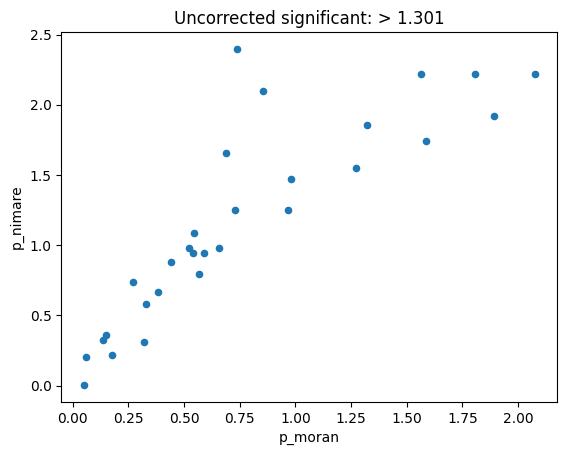

In [14]:
comparison = pd.DataFrame({
    "rho":      rho.T["pain_ale"],
    "p_moran":  p_std.T["pain_ale"],
    "p_nimare": p_nimare.T["pain_ale"],
}).sort_values("p_nimare")

# show
print("Top 10 by NiMARE p-value:")
display(comparison.head(10))

# plot transformed p values
(
    comparison[["p_moran", "p_nimare"]]
    .transform(lambda x: -np.log10(x))
    .plot(kind="scatter", x="p_moran", y="p_nimare", 
          title=f"Uncorrected significant: > {-np.log10(0.05):.03f}")
)

## Binary cluster mode: colocalization with the FWE-significant regions

In binary mode, Y is the FWE-corrected cluster image from `get_binary_cluster_map()`. After parcellation, each parcel receives the **fraction of its voxels that fall inside the significant cluster** — so parcel values are continuous in [0, 1], not truly binary. The observed map typically has values in the range 0–0.5 (most parcels are entirely outside the cluster, boundary parcels have intermediate fractions).

**Why Pearson?** Pearson correlation on a fractional cluster-coverage Y is the natural choice: it directly asks "do parcels with more cluster coverage have higher receptor density?" and is the exact formula of the *point-biserial correlation* when Y is truly binary (0/1). Spearman is less appropriate here because the many tied zeros at the parcel level degrade its sensitivity.

**How binary null maps are constructed — and why their values look different from the observed map:**

For each coordinate-sampling permutation, the null ALE map is converted to z-scores and thresholded at the same voxel-level CDT (p < 0.001, z ≥ 3.09). The resulting binary voxel map is then parcellated as a coverage fraction — exactly as for the observed map. The **FWE cluster extent filter is not applied to null maps**. Applying it would make ~95% of null maps entirely empty by construction: the FWE threshold is the 95th percentile of the max cluster size under the null, so only ~5% of null permutations produce a cluster that survives it. Empty null maps make the colocalization test undefined.

The value range difference is therefore expected and meaningful:
- **Observed map (0→~0.5):** real coordinates cluster strongly in specific brain regions → one large focused cluster → high parcel coverage in that region.
- **Null maps (0→~0.1):** random coordinates scatter across the brain → many small clusters → low fractional coverage per parcel.

This contrast — focused real cluster vs. diffuse random activation — is exactly the signal the permutation test captures.

**NOTE:** Currently, only colocalization with *all* significant ALE clusters simultaneously is supported. Individual clusters can be isolated by masking the binary image, but this requires manual steps not yet validated in this workflow.

### 1: Generate binary NiMARE null maps

In [15]:
# Generate binary null maps (corrector= enables binary cluster mode)
null_maps_bin = null_maps_from_nimare(
    ale_result,
    corrected_result=ale_corrected, # passing the FWE corrector enables binary cluster mode
    parcellation=nsp._parc,
    cluster_stat="size",
    voxel_thresh=0.001,
    alpha=0.05,
    map_label="pain_cluster",       # must match y_labels above
    observed_map=binary_img,        # sanity check: r ≥ 0.99 confirms consistent thresholding
    n_perm=1000,
    seed=42,
    n_proc=-1,
)

INFO:nispace.helpers.nimare:Voxel z-threshold (p<0.001): 3.0902


INFO:nispace.helpers.nimare:Cluster size threshold (FWE alpha=0.05): 106.


INFO:nispace.helpers.nimare:Pre-resampling parcellation to ALE native space.


INFO:nispace.helpers.nimare:Observed-map sanity check passed (r=1.000).


INFO:nispace.helpers.nimare:Generating 1000 binary cluster null maps from NiMARE ALE estimator (n_proc=-1).


...

INFO:nispace.helpers.nimare:=== Validation (cluster mode) ===


INFO:nispace.helpers.nimare:  NiMARE FWE size threshold (from corrector): 106


INFO:nispace.helpers.nimare:  Our null-derived size threshold (95th pctile of 1000 perms): 102.0


INFO:nispace.helpers.nimare:  Ratio (ours / NiMARE): 0.962  (should be ~1.0 for large n_perm; deviations are sampling noise)


INFO:nispace.helpers.nimare:  Re-derived cluster map vs observed_map: r=1.0000  (should be ~1.0; low r → threshold mismatch or wrong cluster_stat)


### 2: Run analysis

INFO:nispace.core.parcellation:Building combined Parcellation 'Yan200+TianS2' from library.


INFO:nispace.core.parcellation:  Common MNI space(s) for combined: ['MNI152NLin2009cAsym', 'MNI152NLin6Asym'].


INFO:nispace.core.parcellation:  Merging 'Yan200' and 'TianS2' for space 'MNI152NLin2009cAsym'.


INFO:nispace.core.parcellation:  Merging 'Yan200' and 'TianS2' for space 'MNI152NLin6Asym'.


INFO:nispace.core.parcellation:  Fetching cx surface data for 'Yan200' in 'fsLR' (for spin tests).


...

INFO:nispace.core.permute:Wrapping provided dict null maps into NullMaps.


INFO:nispace.core.permute:Using provided null maps.


Null colocalizations (pearson, -1 proc): 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 4176.87it/s]


INFO:nispace.core.permute:Calculating exact p-values (tails = {'rho': 'two'}).


INFO:nispace.plotting:Significance annotation: 5/29 p_uncorrected < 0.05, 3/29 p_meffgalwey < 0.05


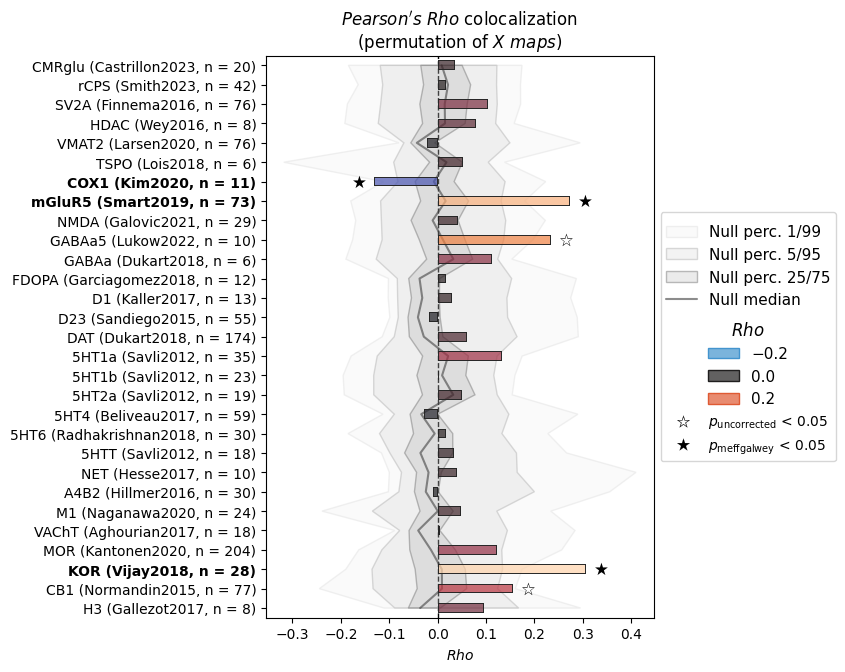

In [16]:
nsp_bin = nimare_colocalization(
    x=pet_maps,
    y={"pain_cluster": binary_img},
    binary_y=True,                  # central parameter: sets some specific defaults
    parcellation=PARC,
    seed=42, 
    n_proc=-1,
    n_perm=1000,
    nimare_nulls=null_maps_bin,     # here, we pass the nimare nulls
    return_nispace_only=True
)

#### 2.1 Inspect null maps

INFO:nispace.plotting:brainplot: threshold='auto' → 0.0006622516666539013


INFO:nispace.plotting:brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


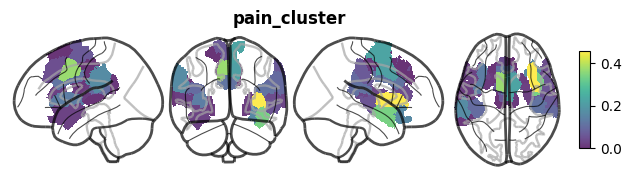

INFO:nispace.core.parcellation:Building combined Parcellation 'Yan200+TianS2' from library.


INFO:nispace.core.parcellation:  Common MNI space(s) for combined: ['MNI152NLin2009cAsym', 'MNI152NLin6Asym'].


INFO:nispace.core.parcellation:  Merging 'Yan200' and 'TianS2' for space 'MNI152NLin2009cAsym'.


INFO:nispace.core.parcellation:  Merging 'Yan200' and 'TianS2' for space 'MNI152NLin6Asym'.


INFO:nispace.core.parcellation:  Fetching cx surface data for 'Yan200' in 'fsLR' (for spin tests).


...

INFO:nispace.core.parcellation:Parcellation 'Yan200+TianS2': validation passed.


INFO:nispace.core.parcellation:Parcellation 'Yan200+TianS2': active space set to 'MNI152NLin2009cAsym'.


INFO:nispace.core.parcellation:Combined parcellation: cx-LH parcels = 100, cx-RH parcels = 100.


INFO:nispace.plotting:brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


(<Figure size 1440x630 with 36 Axes>,
 [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >])

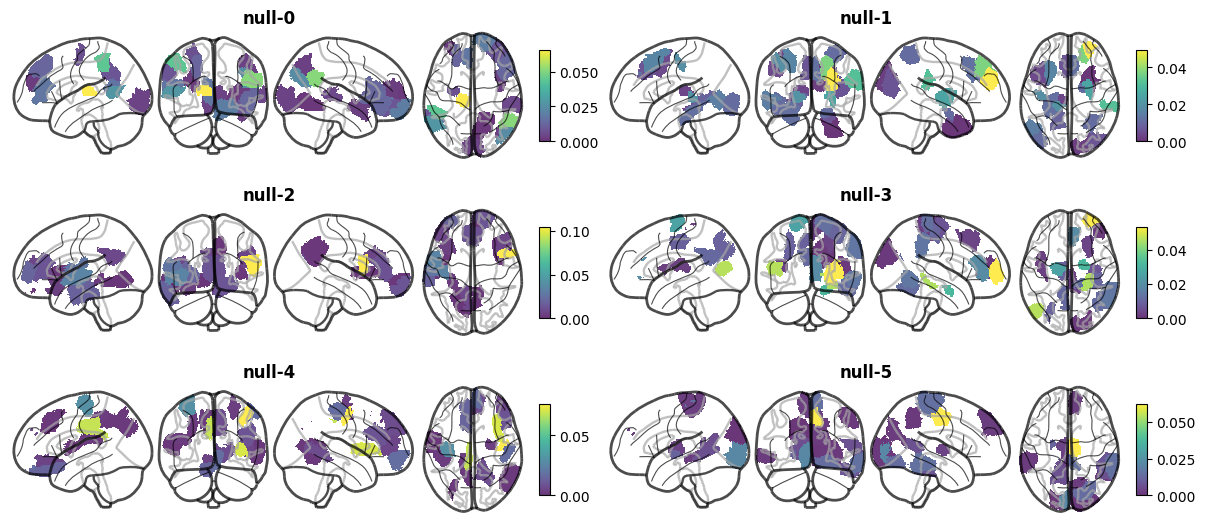

In [17]:
# observed map (parcellated binary -> for each parcel the coverage relative to source cluster)
nsp_bin.plot_brain("y")

# null maps (similarly parcellated binary)
brainplot(
    null_maps_bin["pain_cluster"][:6, :], 
    parcellation=PARC,
    title=[f"null-{i}" for i in range(6)], 
    threshold=0,
    ncols=2,
)

#### 2.2 Results

In [18]:
p_bin = nsp_bin.get_p_values()
rho_bin = nsp_bin.get_colocalizations()

### Extra: Without workflow function

In [19]:
# Set up NiSpace
nsp_bin = NiSpace(
    x=pet_maps, 
    y=binary_img, 
    y_labels=["pain_cluster"],
    binary_y=True,
    parcellation=PARC, 
    seed=42, 
    n_proc=-1
)
nsp_bin.fit()                       # ignore_background_data enforced via binary mode

# Generate nimare nulls (done above -> commented out)
# null_maps_bin = null_maps_from_nimare(
#     ale_result,
#     corrected_result=ale_corrected, # passing the FWE corrector enables binary cluster mode
#     parcellation=nsp._parc,
#     cluster_stat="size",
#     voxel_thresh=0.001,
#     alpha=0.05,
#     map_label="pain_cluster",       # must match y_labels above
#     observed_map=binary_img,        # sanity check: r ≥ 0.99 confirms consistent thresholding
#     n_perm=1000,
#     seed=42,
#     n_proc=-1,
# )

# Run colocalization
nsp_bin.colocalize("pearson")       # pearson to perform appr. point-biserial correlation

# Permute Y (not X) using the NiMARE null maps
nsp_bin.permute("maps", maps_which="Y", maps_nulls=null_maps_bin, n_perm=1000, p_tails="two")

# correct for multiple comparisons
nsp_bin.correct_p()

INFO:nispace.core.parcellation:Building combined Parcellation 'Yan200+TianS2' from library.


INFO:nispace.core.parcellation:  Common MNI space(s) for combined: ['MNI152NLin2009cAsym', 'MNI152NLin6Asym'].


INFO:nispace.core.parcellation:  Merging 'Yan200' and 'TianS2' for space 'MNI152NLin2009cAsym'.


INFO:nispace.core.parcellation:  Merging 'Yan200' and 'TianS2' for space 'MNI152NLin6Asym'.


INFO:nispace.core.parcellation:  Fetching cx surface data for 'Yan200' in 'fsLR' (for spin tests).


...

Colocalizing (pearson, -1 proc): 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 1657.83it/s]

INFO:nispace.core.permute:Wrapping provided dict null maps into NullMaps.


INFO:nispace.core.permute:Using provided null maps.


Null colocalizations (pearson, -1 proc): 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 8670.09it/s]

INFO:nispace.core.permute:Calculating exact p-values (tails = {'rho': 'two'}).


## Conclusion

See below for a comparison of the three final results.

The outcome is very clear. The binary mode without question is the most specific given the pain dataset as input data.  
For a pain dataset, it returns only few significant associations of which the MC-corrected are the K-opioid receptor, the metabotropic glutamate receptor, and the cyclooxygenase-1 enzyme, all of which are – KOR and COX-1 even specifically – related to pain processing.

Based on these results, **we currently recommend to use both continuous and binary NiMARE nulls for spatial colocalization analysis of coordinate-based meta-analyis results, expecting the binary nulls to show higher specificity**.

INFO:nispace.plotting:Significance annotation: 6/29 p_uncorrected < 0.05, 0/29 p_meffgalwey < 0.05


/var/folders/6n/h4150p8d5gz5kbnqv5_406940000gp/T/ipykernel_54529/3645975165.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels())
/var/folders/6n/h4150p8d5gz5kbnqv5_406940000gp/T/ipykernel_54529/3645975165.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().set_visible(False)
INFO:nispace.plotting:Significance annotation: 11/29 p_uncorrected < 0.05, 1/29 p_meffgalwey < 0.05


/var/folders/6n/h4150p8d5gz5kbnqv5_406940000gp/T/ipykernel_54529/3645975165.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().set_visible(False)


INFO:nispace.plotting:Significance annotation: 5/29 p_uncorrected < 0.05, 3/29 p_meffgalwey < 0.05


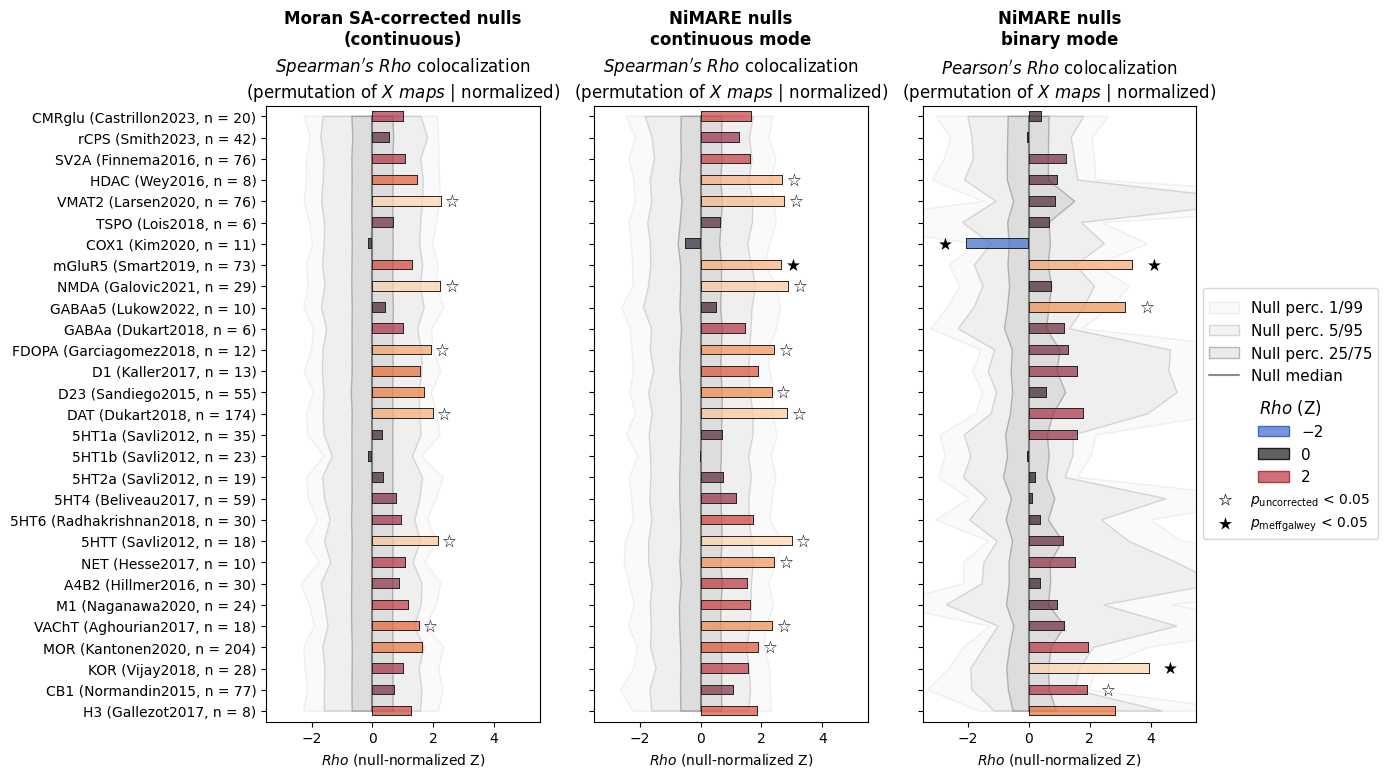

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,3, figsize=(12, 8))
for nispace_obj, ax, title in [
    (nsp_standard, axes[0], "Moran SA-corrected nulls\n(continuous)"),
    (nsp, axes[1], "NiMARE nulls\ncontinuous mode"),
    (nsp_bin, axes[2], "NiMARE nulls\nbinary mode"),
]:
    
    # plot r values normalized against null
    nispace_obj.normalize_colocalizations()    
    nispace_obj.plot(fig=fig, ax=ax, show=False, values="z")
    
    # limit x axis to custom setting
    ax.set_xlim(-3.5 ,5.5)
    
    # layout
    ax.annotate(title, xy=(0.5, 1.1), xycoords="axes fraction", 
                ha="center", size=12, weight="bold")
    if not ax.get_subplotspec().is_first_col():
        ax.set_yticklabels([])
    else:
        ax.set_yticklabels(ax.get_yticklabels())
    if not ax.get_subplotspec().is_last_col():
        ax.legend().set_visible(False)

## Summary

| Mode | Y | `corrected_result=` | What the null maps contain |
|------|---|---------------------|----------------------------|
| Continuous | `result.get_map("stat")` | `None` | Parcellated raw ALE values from random coordinates |
| Binary cluster | `get_binary_cluster_map(corrected)` | `corrected` (MetaResult from `fwe.transform()`) | CDT-thresholded cluster-coverage fractions from random coordinates |

Key points:

- **Which null for what question**: the standard Moran/spin null on X tests whether SA in the reference maps explains the colocalization. The coordinate-sampling null on Y tests whether the spatial convergence of peak coordinates in the meta-analysis explains the colocalization. The two are complementary — use the NiMARE null when you want to honor the ALE generative process.
- **Binary mode uses Pearson**, not Spearman: parcellated Y is a fractional cluster-coverage map (not truly binary), and Pearson directly measures the point-biserial relationship. Spearman degrades due to heavy ties at zero.
- **Binary null maps are CDT-thresholded only** (no FWE extent filter): applying FWE to null maps makes ~95% of them empty by construction (that is what FWE alpha=0.05 means). The lower value range of null maps (0→0.05–0.1) vs observed (0→0.4) reflects that random coordinates produce small scattered clusters, not focused ones.
- `maps_which="Y"` in `permute()` — the null maps replace Y (the meta-analytic image), not X (the receptor maps).
- `map_label=` must equal `y_labels=` in NiSpace — the dict key routes the null array to the correct Y map.
- `observed_map=` triggers an internal r ≥ 0.99 sanity check — always pass it during development to catch space or threshold mismatches early.
- Requires `pip install nimare`; NiMARE ≥ 0.2.0; volumetric/MNI parcellation only (surface parcellations not supported).